In [ ]:
# pydantic : 강제성을 띰
# 객체지향 ... 캡슐화 ... 프레임워크
# 


In [ ]:
from typing import List, Literal
from pydantic import BaseModel, Field

# field id는 강제할 수 있음. 
# yes, no만 가능

class GradeDocuments(BaseModel):
    """문서 관련성 평가 스키마"""
    is_relevant: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )

GradeDocuments(is_relevant='yes')
GradeDocuments(is_relevant='no')
GradeDocuments(is_relevant='maybe')


# Literal["yes", "no"] --->  yes, no만 가능 (강제성을 가짐)
# GradeDocuments(is_relevant='maybe') --> 하기와 같은 에러 발생
# is_relevant
#   Input should be 'yes' or 'no' [type=literal_error, input_value='maybe', input_type=str]

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

from typing import List, Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv

# LangChain 관련 임포트
from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader, TextLoader
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

# LangGraph 관련 임포트
from langgraph.graph import StateGraph, START, END

# 환경설정
load_dotenv()

if not os.environ.get('OPENAI_API_KEY'):
    raise ValueError('key check!!!!!')


<span style="font-size:14px">

## <span style="color: Gold"> **Corrective RAG(CRAG)**

1. Corrective RAG란?
    - **CRAG(Corrective Retrieval-Augmented Generation)**는 일반 RAG의 단점을 보완하기 위해 등장한 개선된 RAG 구조이다.
    - CRAG = RAG + 문서 품질 평가 + 보정 검색(Corrective Search)
    - 즉, 검색된 문서가 부정확하거나 부족하다고 판단되면 스스로 검색 전략을 수정하고 다시 검색하는 RAG이다.

2. 왜 필요한가?
    - 검색 문서가 질문과 무관할 수 있음
    - 검색 문서가 너무 적거나 부족함
    - 검색이 실패하면 LLM이 잘못된 정보로 답변 생성 → 환각(Hallucination) 유발
    - CRAG는 **문서 품질 평가(Grading)**를 통해 이를 바로잡는다

3. CRAG의 핵심 구조
    1) 1차 검색(Search)
        - 벡터DB 등에서 문서를 검색하여 후보 문서를 가져온다.
    2) 문서 평가(Grading)
        - LLM 또는 scoring 모델이 다음을 판단한다:
        - 문서가 질문과 관련 있는가?
        - 답변에 도움이 되는가?
        - 문서 수나 품질이 충분한가?
        - 평가 결과는 다음 두 가지로 나뉜다:
        - 문서 양호 → LLM으로 답변 생성
        - 문서 부족/무관 → 보정 검색 필요
    3) 보정(Correction)
        - 검색 결과가 부족하다고 판단되면 다음 전략 중 하나를 실행한다:
        - 쿼리 재작성(Query Rewriting)
        - BM25, Hybrid Search 추가 수행
        - Multi-query 확장 검색
        - 웹 검색(Web Search)
        - 문서 재랭킹(Reranking)

4. CRAG의 전체 흐름

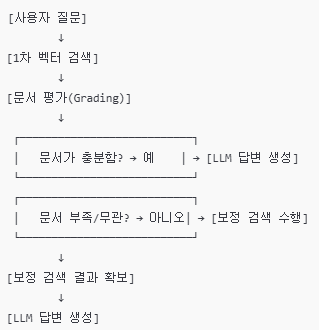

5. CRAG의 장점

| 일반 RAG               | CRAG                              |
| -------------------- | --------------------------------- |
| 검색 실패하면 답이 틀릴 가능성 높음 | 검색 실패해도 재검색 전략으로 보정               |
| 문서 관련성 평가 없음         | LLM이 문서의 “관련성/품질” 평가              |
| 단일 검색 전략만 수행         | Hybrid, Rewriting, Multi-query 활용 |
| 환각 발생 가능             | 문서 부족하면 답변 생성 막고 다시 검색            |


6. CRAG에서 자주 쓰는 보정 전략
    - 🔹 Query Rewriting(쿼리 재작성)
        - LLM이 질문을 더 검색 친화적으로 재작성한다.
        - 예: "강아지가 갑자기 구토할 때 어떻게 해야 해요?" → "강아지 구토 원인 및 응급처치"
    - 🔹 Multi-query Search
        - 질문과 비슷한 의미의 여러 버전을 만들어 여러 번 검색한 뒤 통합한다.
    - 🔹 Hybrid Search
        - BM25(키워드)
        - Vector Search(의미 검색)
        - 두 가지 결과를 결합.
    - 🔹 Reranking
        - 검색 결과를 다시 정렬하여 품질 높은 문서만 선택한다.
    - 🔹 Web Search
        - 내부 문서가 충분하지 않을 때 외부 정보를 병합한다.

START
  |
  v
retrieve 노드
(VectorDB 내부 문서 검색)
  |
  v
grade_documents 노드
(문서 관련성 평가)
  |--- 관련 문서 있음 ---> generate 노드
  |                          (답변 생성)
  |                               |
  |                               v
  |                               END
  |
  |--- 관련 문서 없음 ---> web_search 노드
                               (외부 웹 검색)
                                      |
                                      v
                               generate 노드
                               (답변 생성)
                                      |
                                      v
                                     END


In [19]:
# 상태 정의
class CGRAGState(TypedDict):
    question : str
    documents : List[Document]  # 내부 문서 검색결과
    filtered_documents: List[Document] # 이 코드 추가
    web_search_needed : str  # 웹 검색 여부 (yes / no)
    context : str       # 답변 생성을 위한 문서 컨텍스트
    answer : str        # 최종 답변
    grade_results : List[str]  # 각 문서별 관련성 평가 결과 (relevant / not_relavant)


# 문서 로드
path = "C:/00AI/LLM/20openai/sample_docs_20251128"
loader = DirectoryLoader(
    path=path,
    glob='**/*.txt',
    loader_cls=TextLoader,
    loader_kwargs={'encoding':'utf-8'}
    )
docs = loader.load()

# 텍스트 분할
text_spliter = RecursiveCharacterTextSplitter(
    chunk_size = 300, 
    chunk_overlap = 50,
    separators= ['\n\n', '\n', '.', ',', ' ']
)

doc_splits = text_spliter.split_documents(docs)


# 임베딩 및 vectorDB
vectorstores = Chroma.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings(model='text-embedding-3-small'),
    collection_name='langgraph3'
)


# 리트리버
retriever = vectorstores.as_retriever(search_kwargs = {'k':3})

print(f'vectorDB 구축 완료, chunk개수 : {len(doc_splits)}')




############## LLM이 문서 관련성을 평가!!!!!!!!!!!
# 문서 관련성 평가를 위한 Grader 정의
# CRAG는 "교정된 RAG" → 내부 문서가 유용한지 LLM이 판단 후, 필요 시 외부 검색 수행.
from pydantic import BaseModel, Field
class GradeDocuments(BaseModel):  # 출력 형식을 Pydantic 모델로 강제 → binary_score = 'yes' / 'no'
    '''문서 관련성 평가 결과를 위한 pydantic 모델'''
    binary_score : str = Field(description="문서가 질문과 관련이 있으면 'yes' 없으면 'no'")

grader_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
structrued_grader = grader_llm.with_structured_output(GradeDocuments)  #LLM이 출력하는 값을 Pydantic 모델 형태로 강제(pydantic validation 적용)하는 기능
grade_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 검색된 문서가 사용자의 질문에 답변하는데 관련이 있는지 평가하는 전문가 입니다.
                
                평가기준:
                - 문서가 질문의 키워드나 의미와 연관되어 있다면 '관련있음'으로 평가
                - 답변에 도움이 될 가능성이 조금이라도 있다면 '관련있음'
                - 완전히 무관한 내용이면 '관련없음'
                
                엄격하게 평가하지 말고, 약간의 연관성이라도 있으면 'yes'를 반환하세요.'''),
    ('human','''질문: {question}
                문서내용: {document}
                이 문서가 질문과 관련이 있습니까? 'yes' 또는 'no'로만 답하세요.''' )
])

document_grader = grade_prompt | structrued_grader


def retriever_node (state:CGRAGState) -> dict:
    '''내부 문서 검색 노드'''
    question = state['question']
    documents = retriever.invoke(question)
    return {
        'documents': documents,
        'question' : question
    }

def grader_documents_node(state:CGRAGState) -> dict :
    '''문서관련성 평가 노드
    - 검색된 문서의 관련성 여부를 llm이 평가
    - 관련이 없으면 web 검색 플래그를 활성'''
    question = state['question']
    documents = state['documents']
    filtered_docs, grade_results = [], []
    for i, doc in enumerate(documents, 1):
        # 각 문서의 관련성 평가
        score = document_grader.invoke({
            'question' : question,
            'document' : doc.page_content
        })
        grade = score.binary_score.lower()  # grade 'yes', 'no' ?????????????
        if grade == 'yes':
            filtered_docs.append(doc)
            grade_results.append('relevant')
        else:
            grade_results.append('not_relevant')


    # 관련 문서가 없으면 웹 검색 필요
    if len(filtered_docs) == 0:
        web_search_needed = "Yes"
        print("관련 문서 없음 → 웹 검색 필요!")
    else:
        web_search_needed = "No"
        print(f"{len(filtered_docs)}개 관련 문서 확보!")
    
    return {
        **state,  # 기존 state 유지
        "filtered_documents": filtered_docs,  # 필터링된 관련 문서만 저장
        "web_search_needed": web_search_needed,   # 조건부 분기 판단용
        "grade_results": grade_results  # 문서별 관련성 평가 결과
    }



def web_search_node(state: CGRAGState) -> dict:
    """
    웹 검색 노드 (시뮬레이션)
    
    실제 환경에서는 Tavily API나 다른 검색 API를 사용합니다.
    여기서는 학습 목적으로 시뮬레이션합니다.
    """
    print("\n[WEB SEARCH 노드] 외부 웹 검색 수행 중...")
    
    question = state["question"]
    
    # 웹 검색 시뮬레이션 (실제로는 Tavily API 등 사용)
    # 실제 구현 예시:
    # from langchain_community.tools.tavily_search import TavilySearchResults
    # web_search = TavilySearchResults(k=3)
    # web_results = web_search.invoke({"query": question})
    

    # 시뮬레이션된 웹 검색 결과
    simulated_web_results = f"""
    [웹 검색 결과 - 시뮬레이션]
    
    질문 '{question}'에 대한 웹 검색 결과:
    
    1. LLM(Large Language Model) 관련 최신 정보:
    - LLM은 자연어 처리에서 혁신적인 발전을 이루고 있습니다.
    - OpenAI, Anthropic, Google 등이 주요 제공자입니다.
    - RAG, Fine-tuning, Prompt Engineering이 주요 활용 기법입니다.
    
    2. AI 에이전트 트렌드:
    - 자율적인 AI 에이전트가 주목받고 있습니다.
    - LangGraph, AutoGPT 등이 대표적인 프레임워크입니다.
    - 멀티 에이전트 시스템이 복잡한 작업을 수행합니다.
    
    출처: 시뮬레이션된 웹 검색 (실제 환경에서는 Tavily API 사용)
    """
    
    # 웹 검색 결과를 Document 형태로 변환
    web_doc = Document(
        page_content=simulated_web_results,
        metadata={"source": "web_search", "type": "external"}
    )
    
    # 기존 필터링된 문서에 웹 검색 결과 추가
    filtered_docs = state.get("filtered_documents", [])
    filtered_docs.append(web_doc)
    
    print("웹 검색 완료! 결과가 문서에 추가됨")
    
    return {
        **state,
        "filtered_documents": filtered_docs
    }




def generate_node(state: CGRAGState) -> dict:
    """
    답변 생성 노드
    필터링된 문서(내부 문서 + 웹 검색 결과)를 바탕으로 답변을 생성합니다.
    """
    print("\n[GENERATE 노드] 답변 생성 중...")
    
    question = state["question"]
    filtered_documents = state["filtered_documents"]
    
    # 컨텍스트 구성
    context = "\n\n---\n\n".join([doc.page_content for doc in filtered_documents])
    
    # 답변 생성 LLM
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 제공된 문맥을 바탕으로 질문에 답변하는 AI 어시스턴트입니다.

규칙:
1. 제공된 문맥 내의 정보를 우선적으로 사용하세요.
2. 답변은 한국어로 명확하고 구조화되게 작성하세요.
3. 웹 검색 결과가 포함된 경우, 해당 정보도 적절히 활용하세요.
4. 확실하지 않은 정보는 추측하지 마세요."""),
        ("human", """문맥(Context):
{context}

질문: {question}

답변:""")
    ])
    
    chain = prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "question": question})
    
    print("답변 생성 완료!")
    
    return {
        "context": context,
        "answer": answer
    }


# 조건부 엣지 함수 정의

def decide_to_generate(state: CGRAGState) -> Literal["generate", "web_search"]:
    """
    문서 평가 결과에 따라 다음 단계를 결정합니다.
    
    - 관련 문서가 있으면 → generate (답변 생성)
    - 관련 문서가 없으면 → web_search (웹 검색)
    
    Returns:
        "generate" 또는 "web_search"
    """
    print("\n[DECISION] 다음 단계 결정 중...")
    
    web_search_needed = state["web_search_needed"]
    
    if web_search_needed == "Yes":
        print("결정: 웹 검색으로 이동")
        return "web_search"
    else:
        print("결정: 답변 생성으로 이동")
        return "generate"


print("조건부 엣지 함수 정의 완료!")

print("\n CRAG StateGraph 구성 및 컴파일 중...")


# StateGraph 생성
    # 여러 **노드(Node)**를 연결하고
    # 각 노드는 **상태(State)**를 받아 처리
    # 조건부 분기(Conditional Edge) 가능 → 워크플로우를 유연하게 설계
    # 최종적으로 질문 → 검색 → 평가 → 생성 → 종료까지 그래프 형태로 제어
    # 즉, 단순한 함수 호출 순서가 아니라 상태(State)를 중심으로 한 그래프 기반 처리 구조입니다.
workflow = StateGraph(CGRAGState)

# 노드 추가
workflow.add_node("retrieve", retriever_node)
workflow.add_node("grade_documents", grader_documents_node)
workflow.add_node("web_search", web_search_node)
workflow.add_node("generate", generate_node)

# 엣지 추가
# START -> retrieve -> grade_documents
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")

# 조건부 엣지: grade_documents 이후 분기
# - 관련 문서 있음 → generate
# - 관련 문서 없음 → web_search
workflow.add_conditional_edges(
    "grade_documents",      # 시작 노드
    decide_to_generate,     # 조건 함수
    {
        "generate": "generate",      # "generate" 반환 시
        "web_search": "web_search"   # "web_search" 반환 시
    }
)

# web_search 이후 generate로 이동
workflow.add_edge("web_search", "generate")

# generate 이후 종료
workflow.add_edge("generate", END)

# 그래프 컴파일
app = workflow.compile()


# response = app.invoke({"question": "LangGraph가 뭐야?"})
# print(response["answer"])




# 각 질문에 대한 출력
test_qeustion = [
    'LangGraph의 핵심 개념을 설명해 주세요',
    'RAG란 무엇인가요?',
    '오늘 서울 날씨는 어떤가요?'  # 내부 문서에 없음
]


for question in test_qeustion:        
    result = app.invoke({
        'question': question,
        'documents': [],
        'doc_scores': [],
        'search_type': "",
        'answer': "",
        
        # 🔥 필수 초기값 추가
        'filtered_documents': [],
        'web_search_needed': "No"
    })

    print("\n======================================")
    print(f"질문: {question}")
    print("--------------------------------------")

    # 1) 답변
    print(f"\n📌 답변:\n{result.get('answer', '(답변 없음)')}")

    # 2) 참조 문서 수
    filtered_docs = result.get("filtered_documents", [])
    print(f"\n📄 참조 문서 수: {len(filtered_docs)}개")

    # 3) 웹 검색 여부 
    web_flag = result.get("web_search_needed", "Unknown")
    print(f"🌐 웹 검색 여부: {web_flag}")

    print("======================================\n")


vectorDB 구축 완료, chunk개수 : 12
조건부 엣지 함수 정의 완료!

 CRAG StateGraph 구성 및 컴파일 중...
3개 관련 문서 확보!

[DECISION] 다음 단계 결정 중...
결정: 답변 생성으로 이동

[GENERATE 노드] 답변 생성 중...
답변 생성 완료!

질문: LangGraph의 핵심 개념을 설명해 주세요
--------------------------------------

📌 답변:
LangGraph의 핵심 개념은 다음과 같습니다:

1. **State(상태)**: 에이전트의 현재 상태를 나타내는 데이터 구조로, 에이전트가 수행하는 작업의 맥락을 제공합니다.

2. **Node(노드)**: 실제 작업을 수행하는 함수로, 에이전트가 특정 작업을 실행하는 단위를 의미합니다.

3. **Edge(엣지)**: 노드 간의 제어 흐름을 정의하여, 어떤 노드가 다음에 실행될지를 결정합니다.

4. **Conditional Edge**: 특정 조건에 따라 다른 노드로 분기할 수 있는 엣지로, 에이전트의 의사결정 과정을 유연하게 만듭니다.

LangGraph는 이러한 개념들을 바탕으로 상태 기반 에이전트 프레임워크를 구축하며, 순환(Cycle)을 지원하여 복잡한 에이전트 워크플로우를 구현할 수 있습니다.

📄 참조 문서 수: 3개
🌐 웹 검색 여부: No

3개 관련 문서 확보!

[DECISION] 다음 단계 결정 중...
결정: 답변 생성으로 이동

[GENERATE 노드] 답변 생성 중...
답변 생성 완료!

질문: RAG란 무엇인가요?
--------------------------------------

📌 답변:
RAG(Retrieval-Augmented Generation)는 정보 검색과 생성 모델을 결합한 접근 방식입니다. 이 방법은 주어진 질문이나 요청에 대해 관련 정보를 검색한 후, 그 정보를 바탕으로 자연어로 응답을 생성하는 방식입니다. 

RAG의 주요 구성 요소는 다음과 같습니다:

1. **정보 검

In [ ]:
# import os
# import warnings
# warnings.filterwarnings("ignore")

# from typing import List, Literal
# from typing_extensions import TypedDict
# from dotenv import load_dotenv

# # LangChain 관련 임포트
# from langchain_core.documents import Document
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.output_parsers import StrOutputParser
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_chroma import Chroma
# from langchain_community.document_loaders import DirectoryLoader, TextLoader
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# # LangGraph 관련 임포트
# from langgraph.graph import StateGraph, START, END

# # 환경설정
# load_dotenv()

# if not os.environ.get('OPENAI_API_KEY'):
#     raise ValueError('key check....')

# class CGRAState(TypedDict):
#     question : str
#     documents : List[Document]
#     web_search_needed : str   # 웹검색 여부(yes / no)
#     context : str
#     answer : str
#     grade_results : List[str]   #각 문서의 평가 결과

# # 문서 로드
# path = "C:/00AI/LLM/20openai/sample_docs_20251128"
# loader = DirectoryLoader(
#     path=path,
#     glob='**/*.txt',
#     loader_cls=TextLoader,
#     loader_kwargs={'encoding':'utf-8'}
#     )
# docs = loader.load()

# # 텍스트 분할
# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=300, chunk_overlap = 50
# )
# doc_splits = text_splitter.split_documents(docs)
# # 임베딩 및 VectorDB
# vectorstore = Chroma.from_documents(
#     documents=doc_splits,
#     collection_name='crag_collection',
#     embedding=OpenAIEmbeddings(model='text-embedding-3-small')
# )

# # 리트리버 설정 
# retriever = vectorstore.as_retriever(search_kwargs={'k':3})

# print(f' {len(doc_splits)}개 청크로 VectorDB 구축 완료')

# # 문서 관련성 평가를 위한 Grader 정의
# from pydantic import BaseModel, Field
# class GradeDocuments(BaseModel):
#     '''문서 관련성 평가 결과를 위한 pydantic 모델'''
#     binary_score: str  = Field(description="문서가 질문과 관련이 있으면 'yes, 없으면 no")

# # llm
# grader_llm = ChatOpenAI(model = 'gpt-4o-mini',temperature=0)
# structured_grader =  grader_llm.with_structured_output(GradeDocuments)
# grade_prompt = ChatPromptTemplate.from_messages([
#     ('system','''당신은 검색된 문서가 사용자의 질문에 답변하는데 관련이 있는지 평가하는 전문가 입니다.
     
#      평가기준:
#      - 문서가 질문의 키워드나 의미와 연관되어 있다면 '관련있음'으로 평가
#      - 답변에 도움이 될 가능성이 조금이라도 있다면 '관련있음'
#      - 와전히 무관한 내용이면 '관련없음'

#      엄격하게 평가하지 말고, 약간의 연관성이라도 있으면 'yes'를 반환하세요     
# '''),
# ('human','''질문:{question}
 
#  문서내용:
#  {document}

#  이 문서가 질문과 관련이 있습니까? 'yes' 또는 'no'로만 답하세요
#  ''')
# ])

# document_grader = grade_prompt | structured_grader

# def retrieve_node(state:CGRAState) -> dict:
#     '''내부 문서 검색 노드'''
#     question = state['question']
#     documents =  retriever.invoke(question)
#     return {
#         'documents':documents,
#         'question' : question
#     }

# def grade_documents_node(state:CGRAState) -> dict:
#     '''문서관련성 평가 노드
#     검색된 문서의 관련성 여부를 llm 평가 
#     관련없으면 웹 검색 플래그를 활성
#     '''
#     question = state['question']
#     documents = state['documents']
#     filtered_docs, grade_results = [],[]
#     for i, doc in enumerate(documents,1):
#         # 각 문서의 관련성 평가
#         score = document_grader.invoke({
#             'question' : question,
#             'document' : doc.page_content
#         })
#         grade = score.binary_score.lower()
#         if grade == 'yes':
#             filtered_docs.append(doc)
#             grade_results.append("relevant")
#         else:
#             grade_results.append("not_relevant")
#      # 관련 문서가 없으면 웹 검색 필요
#     if len(filtered_docs) == 0:
#         web_search_needed = "Yes"
#         print("   관련 문서 없음 → 웹 검색 필요!")
#     else:
#         web_search_needed = "No"
#         print(f"  {len(filtered_docs)}개 관련 문서 확보!")
    
#     return {
#         **state,  # 기존 state 유지
#         "filtered_documents": filtered_docs,
#         "web_search_needed": web_search_needed,
#         "grade_results": grade_results
#     }

# def web_search_node(state: CGRAState) -> dict:
#     """
#     웹 검색 노드 (시뮬레이션)
    
#     실제 환경에서는 Tavily API나 다른 검색 API를 사용합니다.
#     여기서는 학습 목적으로 시뮬레이션합니다.
#     """
#     print("\n   [WEB SEARCH 노드] 외부 웹 검색 수행 중...")
    
#     question = state["question"]
    
#     # 웹 검색 시뮬레이션 (실제로는 Tavily API 등 사용)
#     # 실제 구현 예시:
#     # from langchain_community.tools.tavily_search import TavilySearchResults
#     # web_search = TavilySearchResults(k=3)
#     # web_results = web_search.invoke({"query": question})
    
#     # 시뮬레이션된 웹 검색 결과
#     simulated_web_results = f"""
#     [웹 검색 결과 - 시뮬레이션]
    
#     질문 '{question}'에 대한 웹 검색 결과:
    
#     1. LLM(Large Language Model) 관련 최신 정보:
#        - LLM은 자연어 처리에서 혁신적인 발전을 이루고 있습니다.
#        - OpenAI, Anthropic, Google 등이 주요 제공자입니다.
#        - RAG, Fine-tuning, Prompt Engineering이 주요 활용 기법입니다.
    
#     2. AI 에이전트 트렌드:
#        - 자율적인 AI 에이전트가 주목받고 있습니다.
#        - LangGraph, AutoGPT 등이 대표적인 프레임워크입니다.
#        - 멀티 에이전트 시스템이 복잡한 작업을 수행합니다.
    
#     출처: 시뮬레이션된 웹 검색 (실제 환경에서는 Tavily API 사용)
#     """
    
#     # 웹 검색 결과를 Document 형태로 변환
#     web_doc = Document(
#         page_content=simulated_web_results,
#         metadata={"source": "web_search", "type": "external"}
#     )
    
#     # 기존 필터링된 문서에 웹 검색 결과 추가
#     filtered_docs = state.get("filtered_documents", [])
#     filtered_docs.append(web_doc)
    
#     print("   웹 검색 완료! 결과가 문서에 추가됨")
    
#     return {
#         **state,
#         "filtered_documents": filtered_docs
#     }


# def generate_node(state: CGRAState) -> dict:
#     """
#     답변 생성 노드
#     필터링된 문서(내부 문서 + 웹 검색 결과)를 바탕으로 답변을 생성합니다.
#     """
#     print("\n   💬 [GENERATE 노드] 답변 생성 중...")
    
#     question = state["question"]
#     filtered_documents = state["filtered_documents"]
    
#     # 컨텍스트 구성
#     context = "\n\n---\n\n".join([doc.page_content for doc in filtered_documents])
    
#     # 답변 생성 LLM
#     llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    
#     prompt = ChatPromptTemplate.from_messages([
#         ("system", """당신은 제공된 문맥을 바탕으로 질문에 답변하는 AI 어시스턴트입니다.

# 규칙:
# 1. 제공된 문맥 내의 정보를 우선적으로 사용하세요.
# 2. 답변은 한국어로 명확하고 구조화되게 작성하세요.
# 3. 웹 검색 결과가 포함된 경우, 해당 정보도 적절히 활용하세요.
# 4. 확실하지 않은 정보는 추측하지 마세요."""),
#         ("human", """문맥(Context):
# {context}

# 질문: {question}

# 답변:""")
#     ])
    
#     chain = prompt | llm | StrOutputParser()
#     answer = chain.invoke({"context": context, "question": question})
    
#     print("   답변 생성 완료!")
    
#     return {
#         "context": context,
#         "answer": answer
#     }


# # 조건부 엣지 함수 정의

# def decide_to_generate(state: CGRAState) -> Literal["generate", "web_search"]:
#     """
#     문서 평가 결과에 따라 다음 단계를 결정합니다.
    
#     - 관련 문서가 있으면 → generate (답변 생성)
#     - 관련 문서가 없으면 → web_search (웹 검색)
    
#     Returns:
#         "generate" 또는 "web_search"
#     """
#     print("\n   [DECISION] 다음 단계 결정 중...")
    
#     web_search_needed = state["web_search_needed"]
    
#     if web_search_needed == "Yes":
#         print("   결정: 웹 검색으로 이동")
#         return "web_search"
#     else:
#         print("   결정: 답변 생성으로 이동")
#         return "generate"


# print("조건부 엣지 함수 정의 완료!")

# print("\n CRAG StateGraph 구성 및 컴파일 중...")

# # StateGraph 생성
# workflow = StateGraph(CGRAState)

# # 노드 추가
# workflow.add_node("retrieve", retrieve_node)
# workflow.add_node("grade_documents", grade_documents_node)
# workflow.add_node("web_search", web_search_node)
# workflow.add_node("generate", generate_node)

# # 엣지 추가
# # START -> retrieve -> grade_documents
# workflow.add_edge(START, "retrieve")
# workflow.add_edge("retrieve", "grade_documents")

# # 조건부 엣지: grade_documents 이후 분기
# # - 관련 문서 있음 → generate
# # - 관련 문서 없음 → web_search
# workflow.add_conditional_edges(
#     "grade_documents",      # 시작 노드
#     decide_to_generate,     # 조건 함수
#     {
#         "generate": "generate",      # "generate" 반환 시
#         "web_search": "web_search"   # "web_search" 반환 시
#     }
# )

# # web_search 이후 generate로 이동
# workflow.add_edge("web_search", "generate")

# # generate 이후 종료
# workflow.add_edge("generate", END)

# # 그래프 컴파일
# app = workflow.compile()


# # 그래프 invoke(질문)
# test_question = [
#     'Langgraph의 핵심 개념을 설명해주세요.',
#     'RAG란 무엇인가요?',
#     '오늘 서울 날씨는 어떤가요?'  # 내부 문서에 없음
# ]

# # 각 질문에 대한 출력
# for quest in test_question:
#     result = app.invoke({
#         'question': quest,
#         'documents':[],
#         'filtered_documents': [],
#         'doc_scores':[],
#         'search_type':"",
#         'answer':""
#         })
#     print(f"-----------\n 질문 {quest}")
#     print(f"\n 답변 : \n {result['answer']}")
#     print(f"\n 검색유형 : {result['search_type']}, 참조문서:{result['documents']}")

 12개 청크로 VectorDB 구축 완료
조건부 엣지 함수 정의 완료!

 CRAG StateGraph 구성 및 컴파일 중...
  3개 관련 문서 확보!

   [DECISION] 다음 단계 결정 중...
   결정: 답변 생성으로 이동

   💬 [GENERATE 노드] 답변 생성 중...


KeyError: 'filtered_documents'